In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Dataset location= C:\Users\Rajiv\.cache\kagglehub\datasets\kartik2112\fraud-detection\versions\1 (local directory)
# Link to original dataset= https://www.kaggle.com/datasets/kartik2112/fraud-detection

In [2]:
pd.set_option("display.max_columns",None)

In [3]:
sns.set_style("whitegrid")

In [4]:
df=pd.read_csv(r"C:\Users\Rajiv\.cache\kagglehub\datasets\kartik2112\fraud-detection\versions\1\fraudTrain.csv")

In [5]:
df.head()
# from here it is just analysis of dataset and constructing various graphs, box plots and heat maps

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [7]:
df.shape

(1296675, 23)

In [8]:
df.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [11]:
df.drop(columns= "Unnamed: 0", inplace=True)

In [12]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='str')

In [13]:
df['dob']= pd.to_datetime(df['dob'])
df['trans_date_trans_time']= pd.to_datetime(df['trans_date_trans_time'])

In [14]:
# Sort by card and time first
df = df.sort_values(by=['cc_num', 'trans_date_trans_time'])

# Calculate time difference between current and previous row for the same card
df['velocity(in hours)'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds()/ 3600
df['velocity(in hours)'] = df['velocity(in hours)'].fillna(720)
# to calcualte the time difference between two transactions for the same card in hours.

In [15]:
# Make sure dates are in datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Find the first transaction for each card
df['first_trans_date'] = df.groupby('cc_num')['trans_date_trans_time'].transform('min')

# Calculate "Tenure" in days
df['tenure_days'] = (df['trans_date_trans_time'] - df['first_trans_date']).dt.days
# this is basically to calculate how long the card is active in days.

In [16]:
df['age']= (df['trans_date_trans_time']-df['dob']).dt.days //365.25
# to calculate the age attribute 

In [17]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'velocity(in hours)', 'first_trans_date',
       'tenure_days', 'age'],
      dtype='str')

In [18]:
df.age

1017       32.0
2724       32.0
2726       32.0
2882       32.0
2907       32.0
           ... 
1294934    64.0
1295369    64.0
1295587    64.0
1296206    64.0
1296427    64.0
Name: age, Length: 1296675, dtype: float64

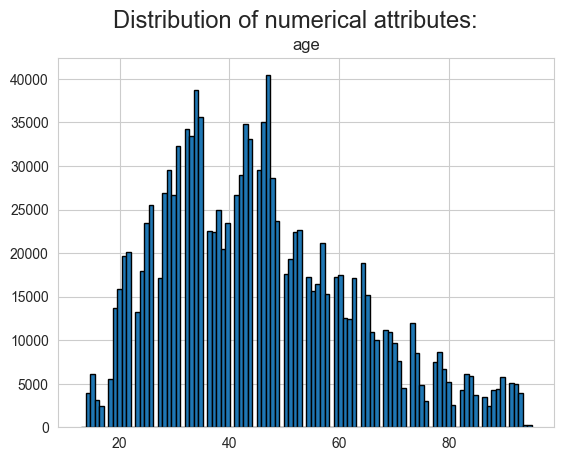

In [19]:
df[["age"]].hist(bins=100, edgecolor="black")
plt.suptitle("Distribution of numerical attributes: ",fontsize= 17)
plt.show()

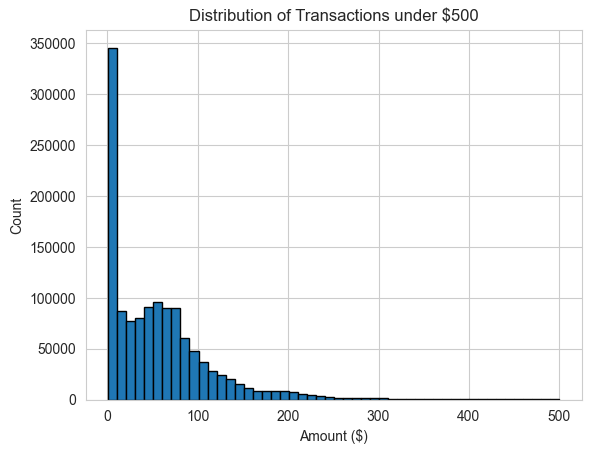

In [20]:
df[df['amt'] < 500]['amt'].hist(bins=50, edgecolor="black")
plt.title("Distribution of Transactions under $500")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.show()

In [ ]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,first_trans_date,tenure_days,velocity(in hours)
1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,43.0048,-108.8964,1645,Information systems manager,1986-02-17,98e3dcf98101146a577f85a34e58feec,1325422035,43.974711,-109.741904,0,32.0,2019-01-01 12:47:15,0,720.000000
2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,43.0048,-108.8964,1645,Information systems manager,1986-02-17,498120fc45d277f7c88e3dba79c33865,1325493897,42.018766,-109.044172,0,32.0,2019-01-01 12:47:15,0,19.961667
2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,43.0048,-108.8964,1645,Information systems manager,1986-02-17,95f514bb993151347c7acdf8505c3d62,1325494056,42.961335,-109.157564,0,32.0,2019-01-01 12:47:15,0,0.044167
2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,43.0048,-108.8964,1645,Information systems manager,1986-02-17,4f0c1a14e0aa7eb56a490780ef9268c5,1325507894,42.228227,-108.747683,0,32.0,2019-01-01 12:47:15,0,3.843889
2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,43.0048,-108.8964,1645,Information systems manager,1986-02-17,3b2ebd3af508afba959640893e1e82bc,1325509846,43.321745,-108.091143,0,32.0,2019-01-01 12:47:15,1,0.542222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294934,2020-06-20 21:04:59,4992346398065154184,"fraud_Berge, Kautzer and Harris",personal_care,60.47,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,ad7dfdf0aaa36cd7985dd1f35ca0e2fc,1371762299,40.475395,-89.076105,0,64.0,2019-01-01 02:34:54,536,8.538889
1295369,2020-06-21 00:41:01,4992346398065154184,fraud_Bernhard Inc,gas_transport,74.29,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,6d427d735c9f9b2fd480f2c24b6525de,1371775261,40.743634,-89.553379,0,64.0,2019-01-01 02:34:54,536,3.600556
1295587,2020-06-21 02:47:59,4992346398065154184,"fraud_Reichert, Rowe and Mraz",shopping_net,246.56,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,9814049bcc69fb31d81f4a907f2fe255,1371782879,40.215418,-88.682562,0,64.0,2019-01-01 02:34:54,537,2.116111
1296206,2020-06-21 08:04:28,4992346398065154184,fraud_Jewess LLC,shopping_pos,2.62,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,ae39b91cd2b4897ddbbf6bf63d3e7b03,1371801868,40.762861,-88.744967,0,64.0,2019-01-01 02:34:54,537,5.274722


In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'age', 'first_trans_date', 'tenure_days',
       'velocity(in hours)'],
      dtype='str')

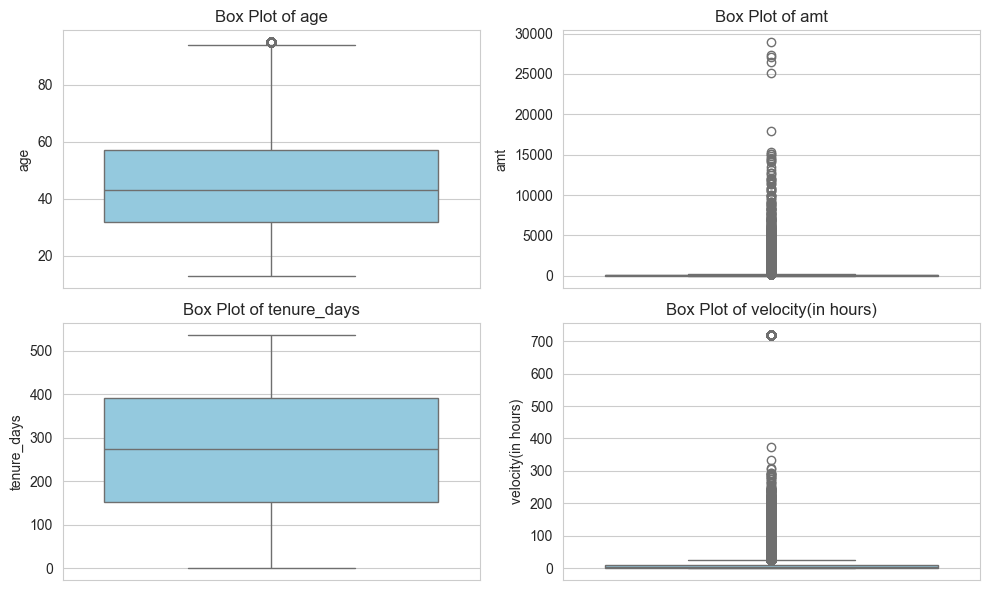

In [ ]:
plt.figure(figsize=(10,6))
for i, col in enumerate(["age","amt","tenure_days","velocity(in hours)"]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

In [22]:
# this is to check the distribution of data in categorical data attributes
categorical_cols= ["gender", "merchant", "state", "city","tenure_days","category"]

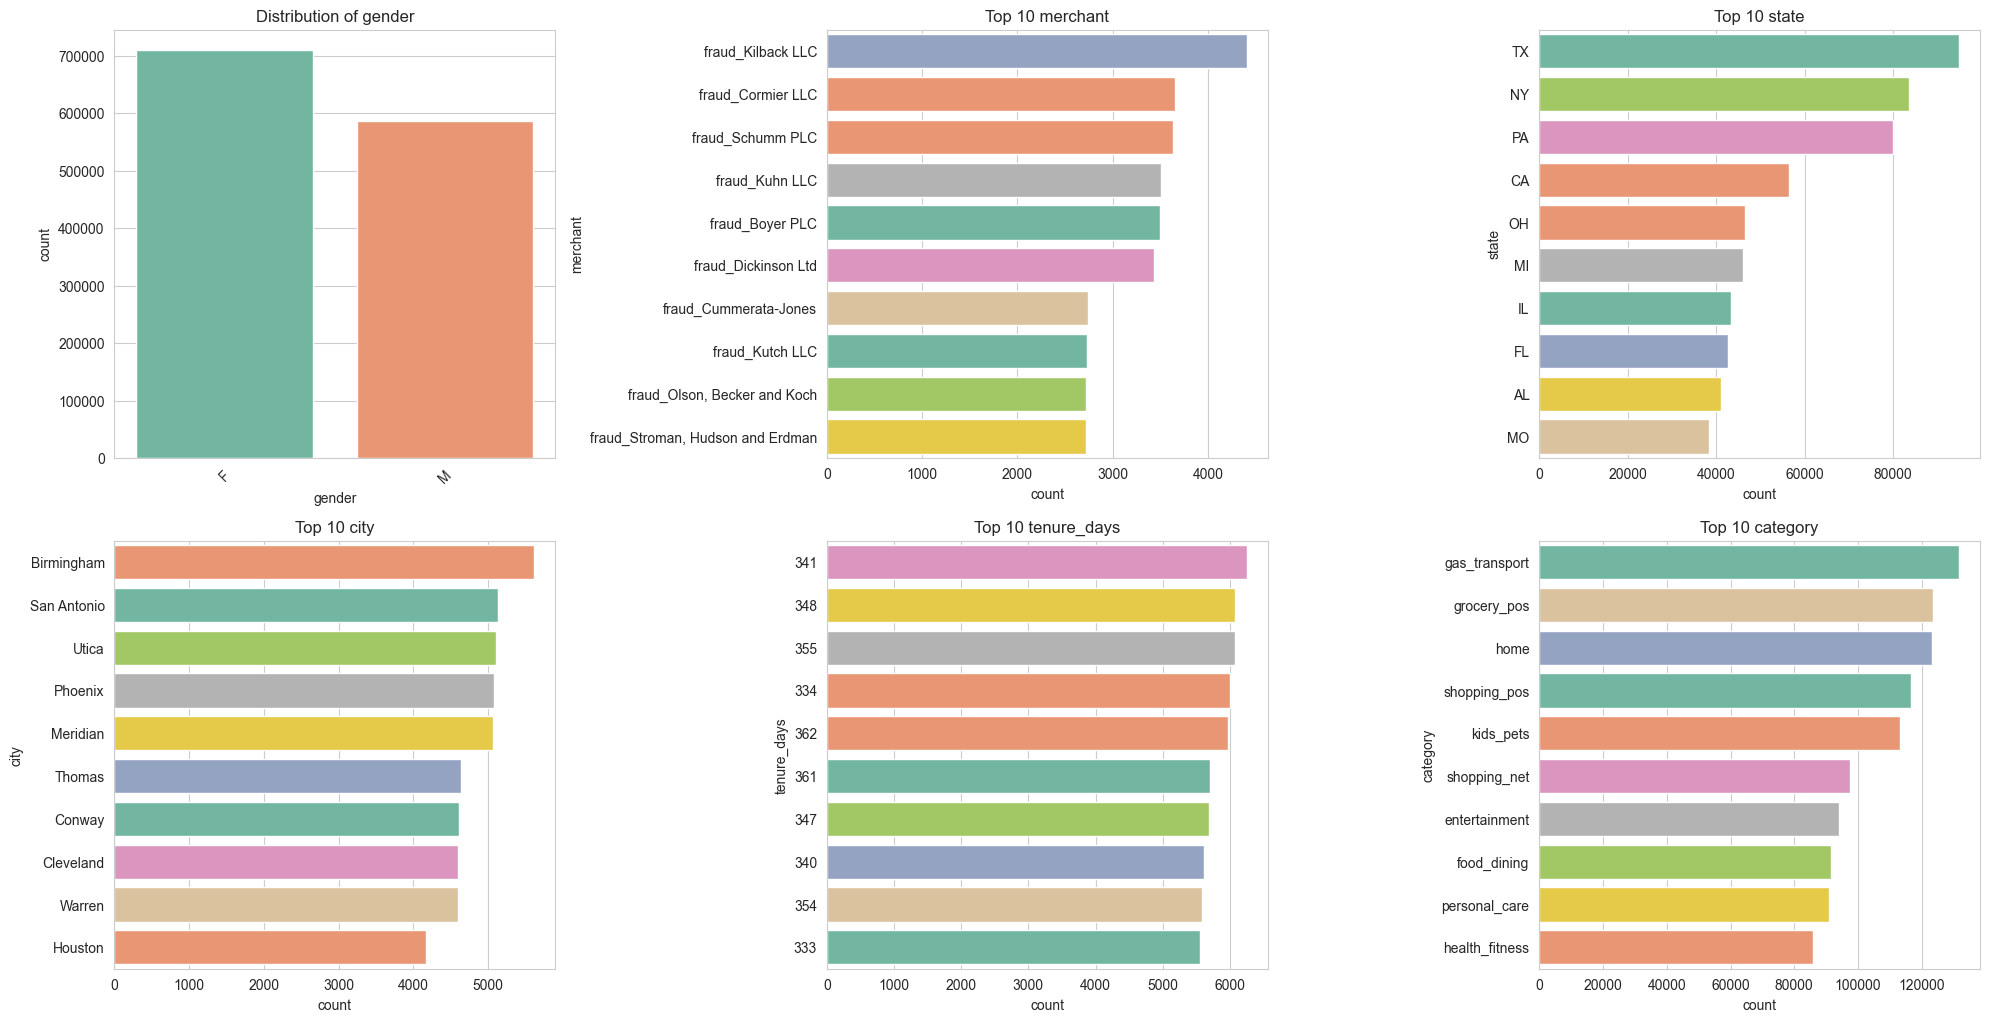

In [23]:
# Fix 1: Use plt.figure (lowercase 'f')
plt.figure(figsize=(20, 15)) 

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    
    # Check if the column has too many values (High Cardinality)
    if df[col].nunique() > 10:
        # Filter for only the Top 10 most frequent items
        top_10 = df[col].value_counts().nlargest(10).index
        data_to_plot = df[df[col].isin(top_10)]
        
        # Use y=col for horizontal bars (better for long names like Jobs/Merchants)
        sns.countplot(data=data_to_plot, y=col, palette="Set2", order=top_10, hue=col, legend=False)
        plt.title(f"Top 10 {col}")
    else:
        # For simple columns (like Gender), keep the vertical bars
        sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index, hue=col, legend=False)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
# this shit is ai generated

In [32]:
corr=df[["age", "amt", "velocity(in hours)", "tenure_days","is_fraud"]].corr()
corr

,age,amt,velocity(in hours),tenure_days,is_fraud
age,1.000000,-0.009755,0.057805,0.018876,0.012251
amt,-0.009755,1.000000,0.001357,-0.003580,0.219404
velocity(in hours),0.057805,0.001357,1.000000,-0.058546,0.011311
tenure_days,0.018876,-0.003580,-0.058546,1.000000,-0.017872
is_fraud,0.012251,0.219404,0.011311,-0.017872,1.000000


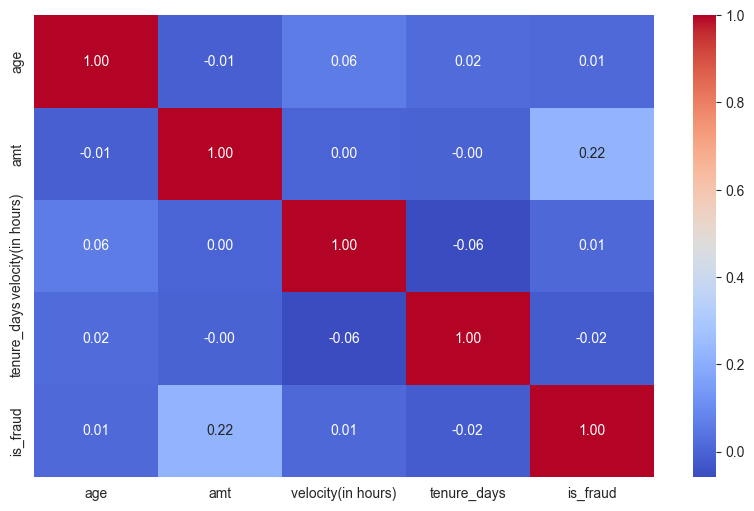

In [34]:
# creating a heatmap to visulise the correlation between the factors
plt.figure(figsize= (10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [36]:
df.groupby("job")["amt"].mean()

job
Academic librarian                       69.623641
Accountant, chartered                   485.706364
Accountant, chartered certified          72.945112
Accountant, chartered public finance     54.839640
Accounting technician                    77.004684
                                           ...    
Water engineer                           70.825936
Water quality scientist                  72.321176
Web designer                             62.053376
Wellsite geologist                       66.432195
Writer                                   92.481012
Name: amt, Length: 494, dtype: float64

In [ ]:
df.groupby("gender")["amt"].mean()
# the above two commands are used to get an idea on how the average transaction amount varies across different categories

gender
F    70.200324
M    70.533350
Name: amt, dtype: float64

In [40]:
df["is_fraud"].value_counts(normalize=True)*100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

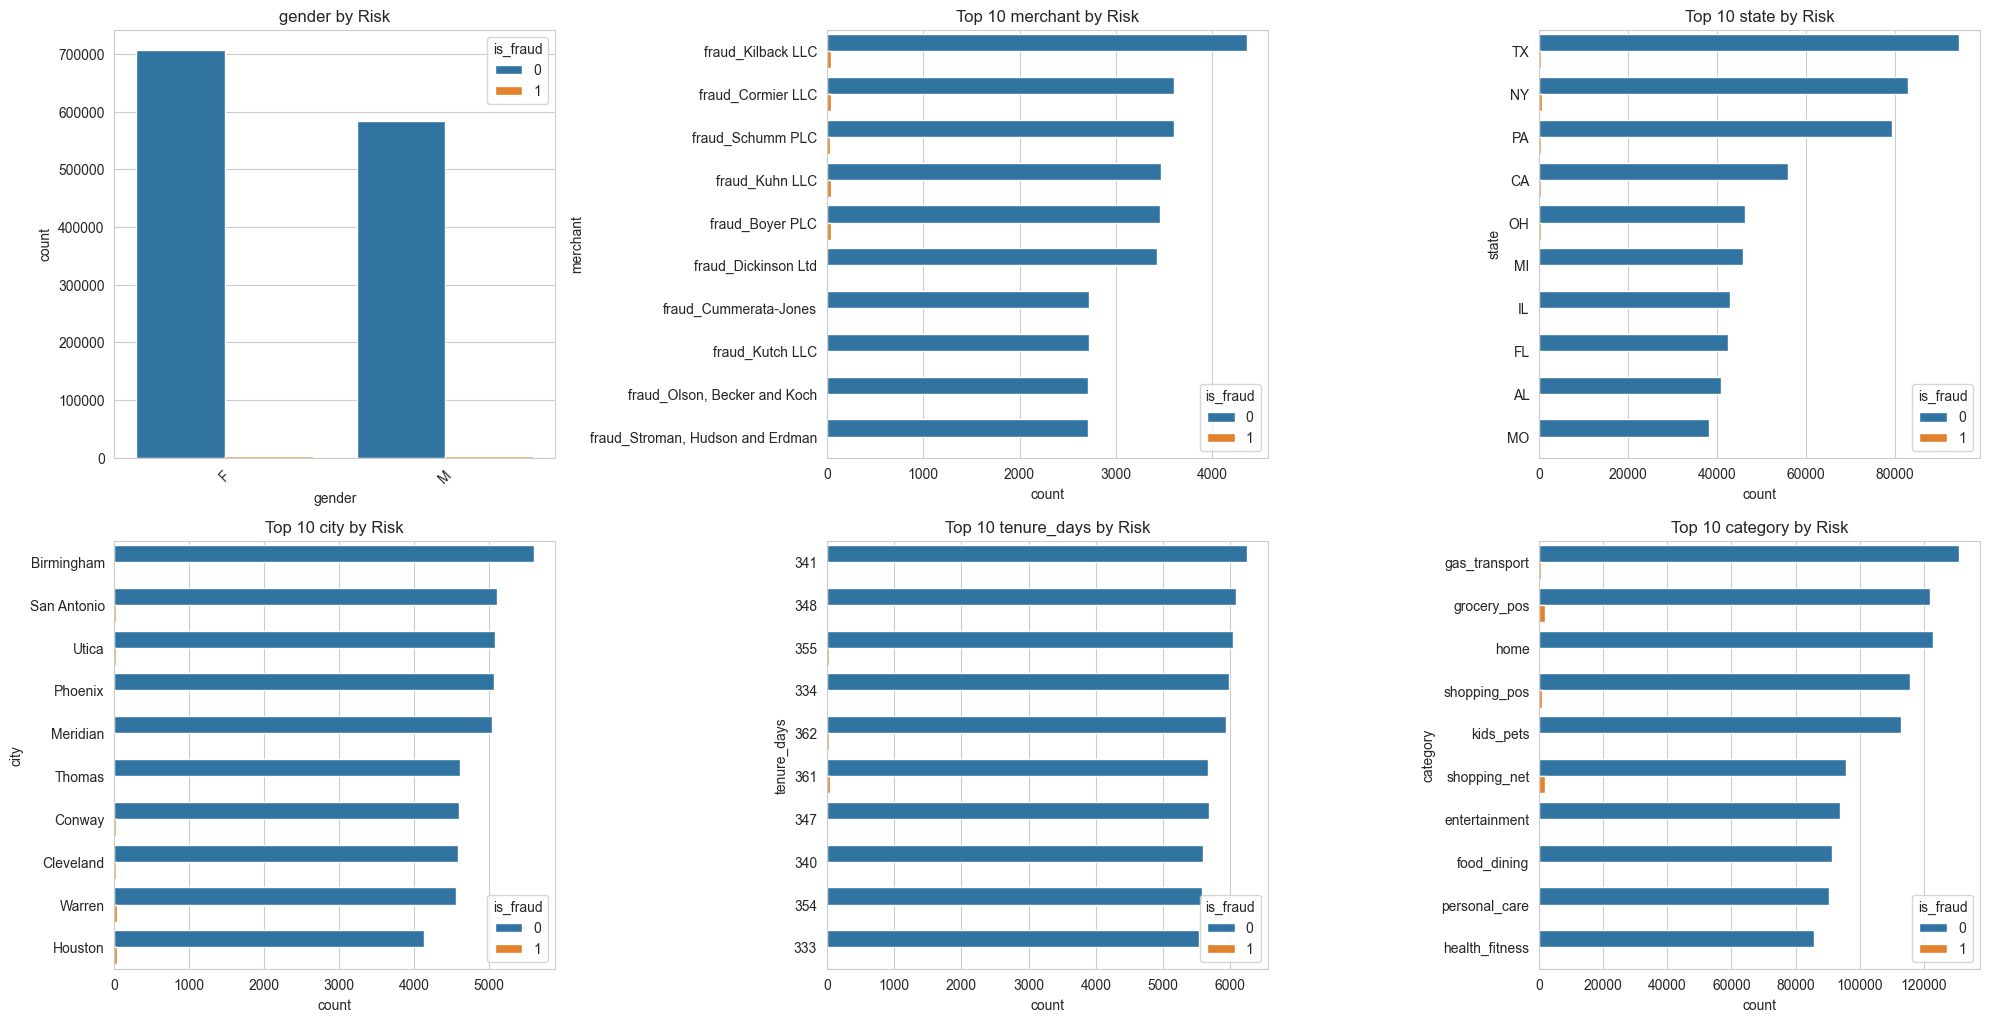

In [ ]:
# the below code is taking all the categoricl_cols and creating count plots for each where red is denoted by fraud and blue is not fraud
plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    if df[col].nunique() > 10:
        top_10 = df[col].value_counts().nlargest(10).index
        # Use y=col (Horizontal) so we can actually read the names
        sns.countplot(data=df[df[col].isin(top_10)], y=col, hue="is_fraud", order=top_10)
        plt.title(f"Top 10 {col} by Risk")
    else:
        sns.countplot(data=df, x=col, hue="is_fraud", order=df[col].value_counts().index)
        plt.title(f"{col} by Risk")
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()